# Workforce Headcount — Exploratory Analysis

This notebook explores a (simulated) company's monthly headcount data, broken
down by department, over four years (2021–2024).

The goal here is the **business analyst layer** that comes *before* forecasting:
understand the data, spot the trends, and translate headcount into cost. The
forecasting itself lives in a separate notebook.

**Questions we'll answer:**
1. How has total headcount changed over time?
2. Which departments are growing, and which are flat?
3. What does attrition (people leaving) look like by department?
4. Is there a seasonal pattern to hiring?
5. How does headcount translate into monthly salary cost?

> The data is synthetic (generated by `src/generate_data.py`) because real HR
> data is private. It's built to behave like real workforce data: a growth
> trend, monthly attrition, seasonal hiring, and random month-to-month noise.

## 1. Load the data

In [1]:
# pandas handles tables, matplotlib makes the charts.
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV. parse_dates tells pandas the 'date' column holds real dates,
# not just text — that lets us do time-based grouping and plotting later.
df = pd.read_csv("../data/headcount_data.csv", parse_dates=["date"])

# .head() shows the first 5 rows so we can sanity-check what we loaded.
df.head()

,date,department,headcount,hires,leavers,avg_annual_salary,monthly_salary_cost,monthly_payroll_tax,monthly_benefits,monthly_overhead,monthly_total_cost
0,2021-01-01,Engineering,43,3,0,130000.0,465833.33,35636.25,55900.0,46583.33,603952.92
1,2021-02-01,Engineering,43,1,1,130000.0,465833.33,35636.25,55900.0,46583.33,603952.92
2,2021-03-01,Engineering,42,1,2,130000.0,455000.00,34807.50,54600.0,45500.00,589907.50
3,2021-04-01,Engineering,42,0,0,130000.0,455000.00,34807.50,54600.0,45500.00,589907.50
4,2021-05-01,Engineering,43,1,0,130000.0,465833.33,35636.25,55900.0,46583.33,603952.92


In [2]:
# A quick overview: how many rows/columns, and what each column's type is.
print("Rows and columns:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Departments:", ", ".join(df["department"].unique()))

Rows and columns: (240, 11)
Date range: 2021-01-01 to 2024-12-01
Departments: Engineering, Sales, Marketing, Finance, Operations


**Takeaway:** We have 240 rows — 5 departments tracked monthly across 48
months. Each row is one department in one month, with its headcount, hires,
leavers, average salary, and salary cost.

## 2. Total headcount over time

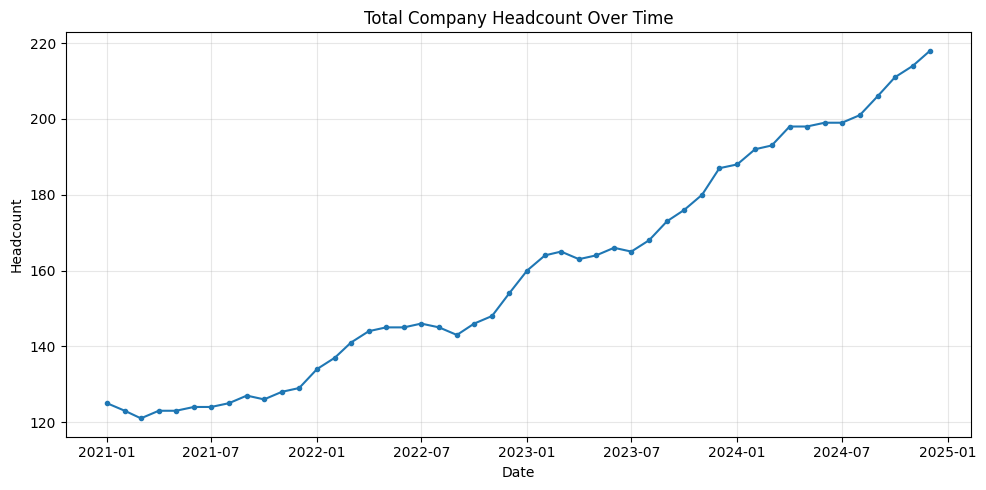

Headcount grew from 125 to 218 (+74%)


In [3]:
# Group all departments together by date and add up their headcount,
# so we get one total-company number per month.
total_headcount = df.groupby("date")["headcount"].sum()

plt.figure(figsize=(10, 5))
plt.plot(total_headcount.index, total_headcount.values, marker="o", markersize=3)
plt.title("Total Company Headcount Over Time")
plt.xlabel("Date")
plt.ylabel("Headcount")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the start vs end so we can quote a concrete growth number.
start, end = total_headcount.iloc[0], total_headcount.iloc[-1]
print(f"Headcount grew from {start} to {end} (+{(end/start - 1)*100:.0f}%)")

**Takeaway:** The company grew steadily over the four years (roughly +74%).
The line isn't perfectly smooth — there's month-to-month wobble and a visible
seasonal rhythm, which we'll look at directly in section 4.

## 3. Headcount by department

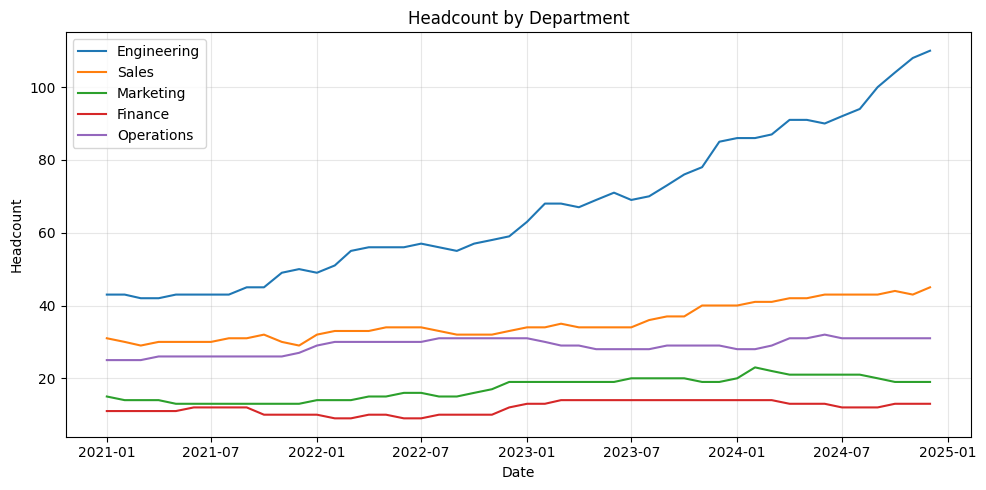

In [4]:
# Plot each department as its own line so we can compare their trajectories.
plt.figure(figsize=(10, 5))
for dept in df["department"].unique():
    sub = df[df["department"] == dept]        # just this department's rows
    plt.plot(sub["date"], sub["headcount"], label=dept)

plt.title("Headcount by Department")
plt.xlabel("Date")
plt.ylabel("Headcount")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Show the start vs end headcount for each department in a small table.
summary = (
    df.sort_values("date")
      .groupby("department")
      .agg(start=("headcount", "first"), end=("headcount", "last"))
)
summary["growth_%"] = ((summary["end"] / summary["start"] - 1) * 100).round(0)
summary.sort_values("growth_%", ascending=False)

,start,end,growth_%
department,,,
Engineering,43,110,156.0
Sales,31,45,45.0
Marketing,15,19,27.0
Operations,25,31,24.0
Finance,11,13,18.0


**Takeaway:** The growth is not evenly spread. **Engineering** more than
doubled and drives most of the company's overall growth. **Sales** grew modestly,
while **Marketing, Finance, and Operations** stayed roughly flat. This is a
common real-world pattern — and it matters for planning, because a company-wide
average would hide the fact that one team is expanding while others hold steady.

## 4. Attrition by department

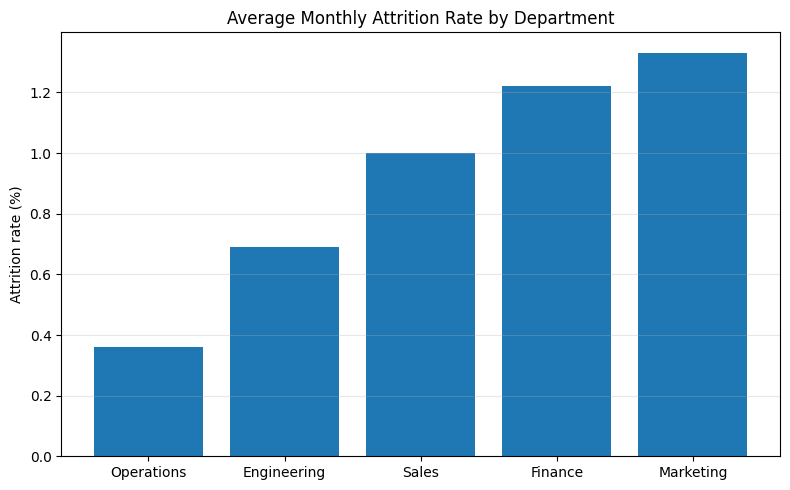

department
Operations     0.36
Engineering    0.69
Sales          1.00
Finance        1.22
Marketing      1.33
dtype: float64

In [6]:
# Attrition = how many people leave, relative to how many are employed.
# We approximate each department's monthly attrition rate as:
#   total leavers across all months / total headcount across all months.
attrition = (
    df.groupby("department")
      .apply(lambda x: x["leavers"].sum() / x["headcount"].sum() * 100,
             include_groups=False)
      .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(attrition.index, attrition.values)
plt.title("Average Monthly Attrition Rate by Department")
plt.ylabel("Attrition rate (%)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

attrition.round(2)

**Takeaway:** Attrition differs by department. Teams with higher attrition
need more hiring just to *stay flat* — a key point for workforce planning, since
a growth target of "stay the same size" still requires backfilling everyone who
leaves.

## 5. Seasonality: when does hiring happen?

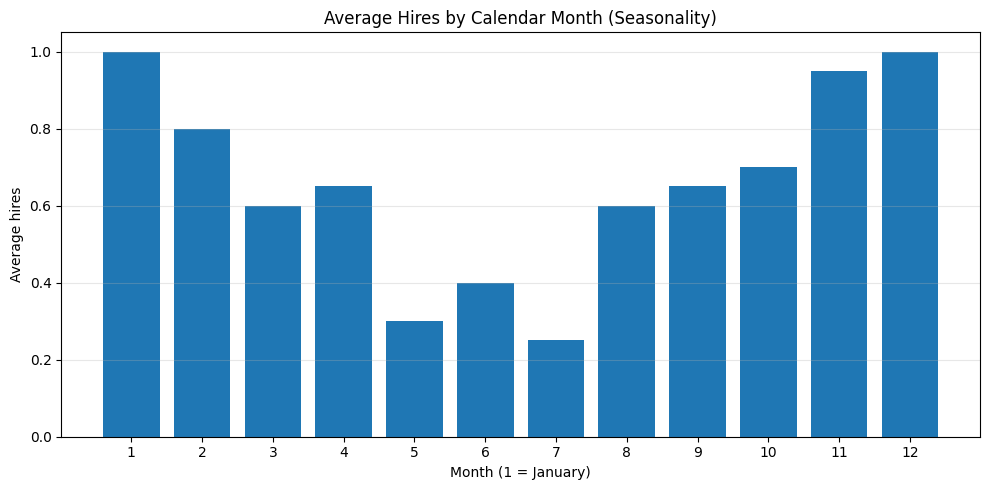

In [7]:
# Pull the calendar month (1-12) out of each date, then average the number
# of hires for each month across all years. If hiring is seasonal, some months
# will consistently show more hires than others.
df["month"] = df["date"].dt.month
seasonal_hires = df.groupby("month")["hires"].mean()

plt.figure(figsize=(10, 5))
plt.bar(seasonal_hires.index, seasonal_hires.values)
plt.title("Average Hires by Calendar Month (Seasonality)")
plt.xlabel("Month (1 = January)")
plt.ylabel("Average hires")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Takeaway:** Hiring is clearly seasonal — strongest early in the year
(fresh budgets in Q1) and slowest in mid-summer. This kind of repeating pattern
is exactly what a good forecasting model needs to capture, and it's why a simple
"draw a straight line" forecast would miss the mark.

## 6. The finance bridge: headcount → fully loaded cost

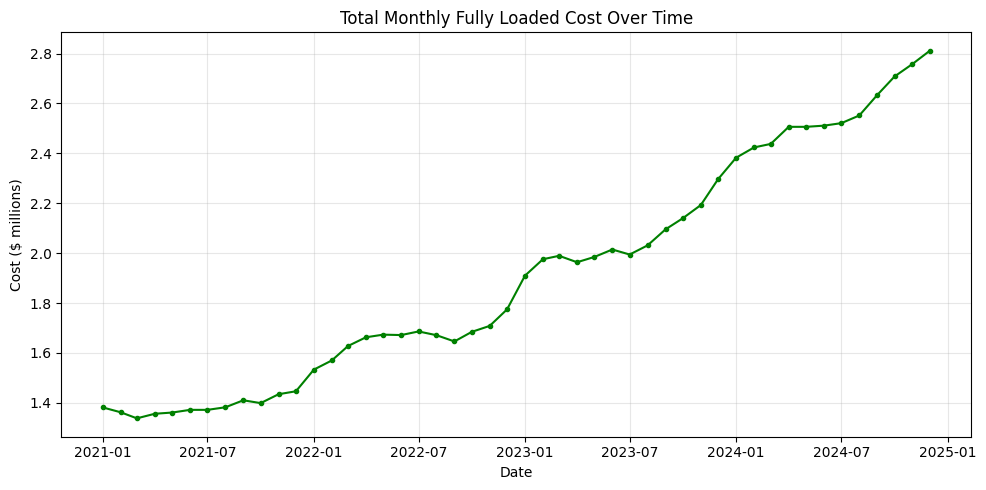

Fully loaded monthly cost grew from $1.38M to $2.81M


In [8]:
# Headcount is only half the planning story; finance teams plan in dollars.
# And an employee costs more than their salary — payroll taxes, benefits, and
# overhead add ~30% on top. Our data includes a 'monthly_total_cost' column
# that captures this fully loaded cost. Sum it across departments per month.
monthly_cost = df.groupby("date")["monthly_total_cost"].sum()

plt.figure(figsize=(10, 5))
# Divide by 1,000,000 so the axis reads in millions ($M) instead of huge numbers.
plt.plot(monthly_cost.index, monthly_cost.values / 1e6,
         marker="o", markersize=3, color="green")
plt.title("Total Monthly Fully Loaded Cost Over Time")
plt.xlabel("Date")
plt.ylabel("Cost ($ millions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fully loaded monthly cost grew from "
      f"${monthly_cost.iloc[0]/1e6:.2f}M to ${monthly_cost.iloc[-1]/1e6:.2f}M")

In [9]:
# How much of the cost is salary vs. the loaded extras? Compare the totals
# across the whole dataset to see the size of the add-ons.
salary_total = df["monthly_salary_cost"].sum() / 1e6
loaded_total = df["monthly_total_cost"].sum() / 1e6
print(f"Total salary cost (all months):       ${salary_total:.1f}M")
print(f"Total fully loaded cost (all months): ${loaded_total:.1f}M")
print(f"The extras (taxes, benefits, overhead) add ${loaded_total - salary_total:.1f}M "
      f"({(loaded_total/salary_total - 1)*100:.0f}% on top of salary).")

Total salary cost (all months):       $70.9M
Total fully loaded cost (all months): $91.9M
The extras (taxes, benefits, overhead) add $21.0M (30% on top of salary).


**Takeaway:** Cost grew faster than headcount alone, because salaries
drift up over time. And the *fully loaded* cost — salary plus payroll taxes,
benefits, and overhead — runs about 30% higher than salary alone. Planning on
salary only would significantly understate the real budget. This is the
connection that makes headcount forecasting useful to a finance team: a
headcount plan is really a *budget* plan once you attach the true cost.

## Summary

- The company grew ~74% over four years, driven mostly by **Engineering**.
- Other departments stayed roughly flat — growth is concentrated, not uniform.
- Attrition varies by department, which affects how much hiring is needed.
- Hiring is **seasonal** (Q1 high, summer low) — important for any forecast.
- Translating headcount into salary cost turns a workforce plan into a budget.

**Next:** the forecasting notebook builds on these patterns (trend + seasonality)
to project future headcount and cost.